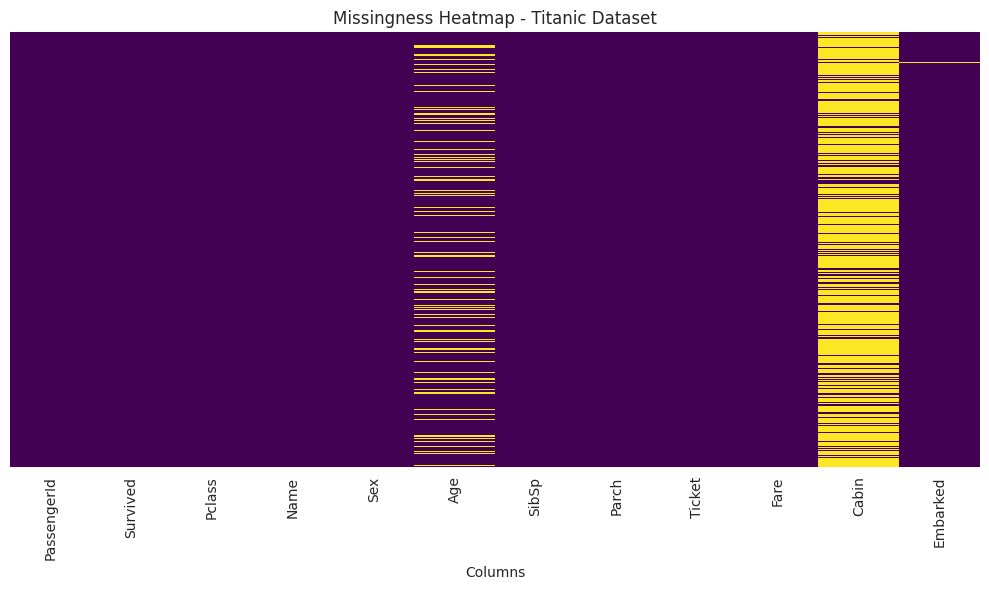

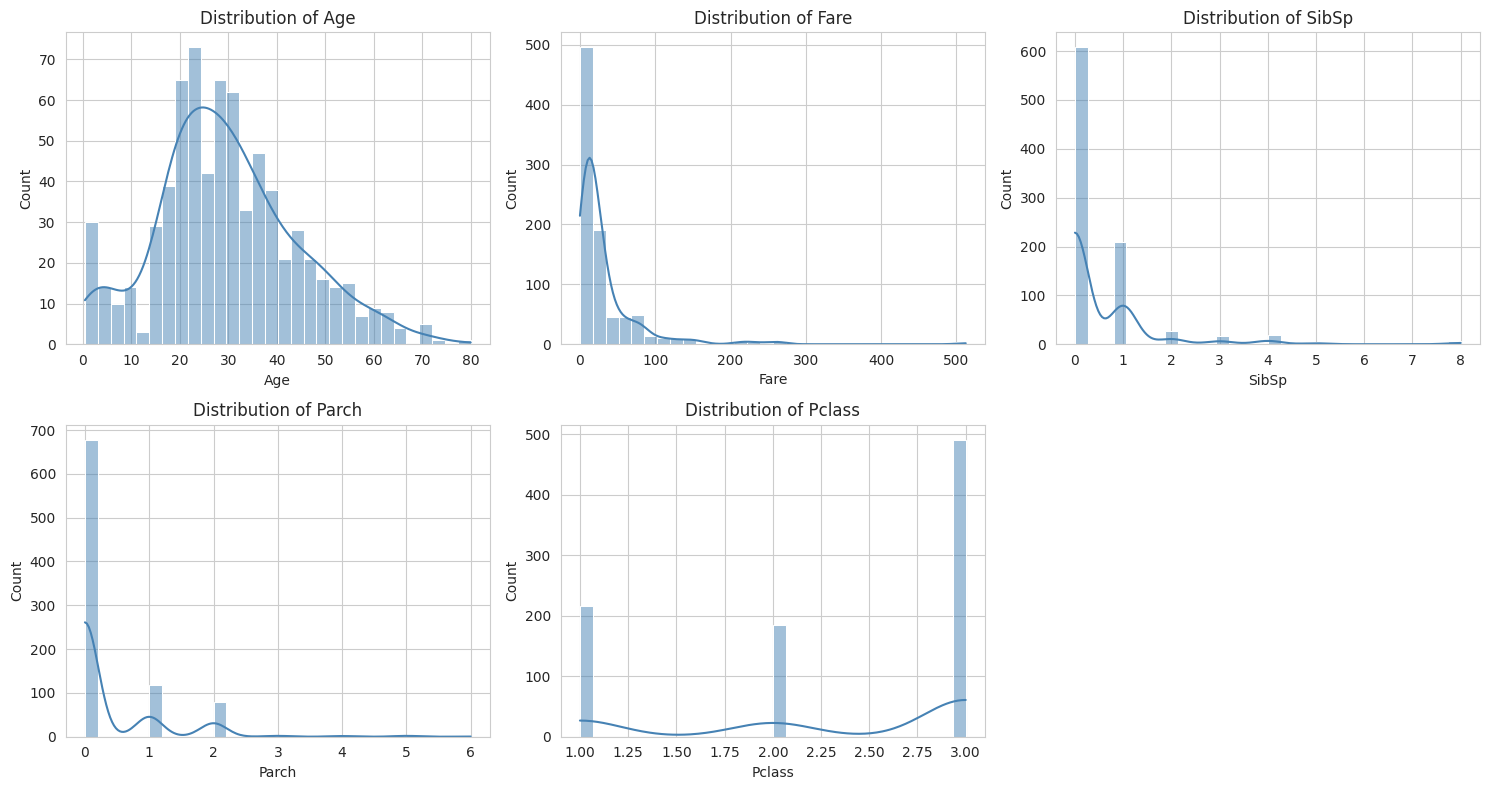

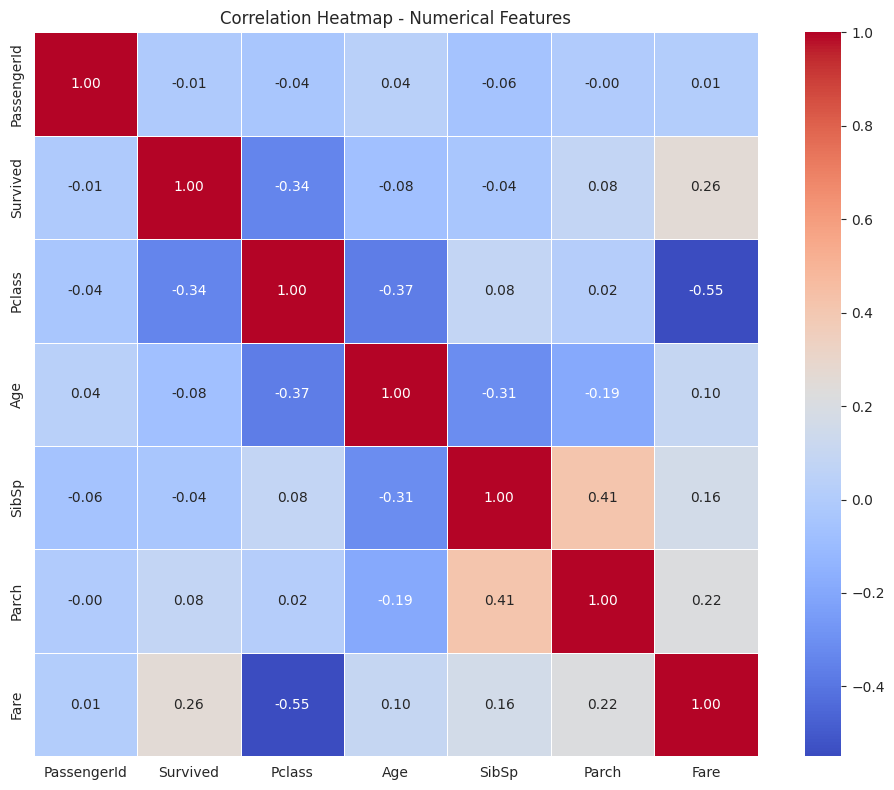

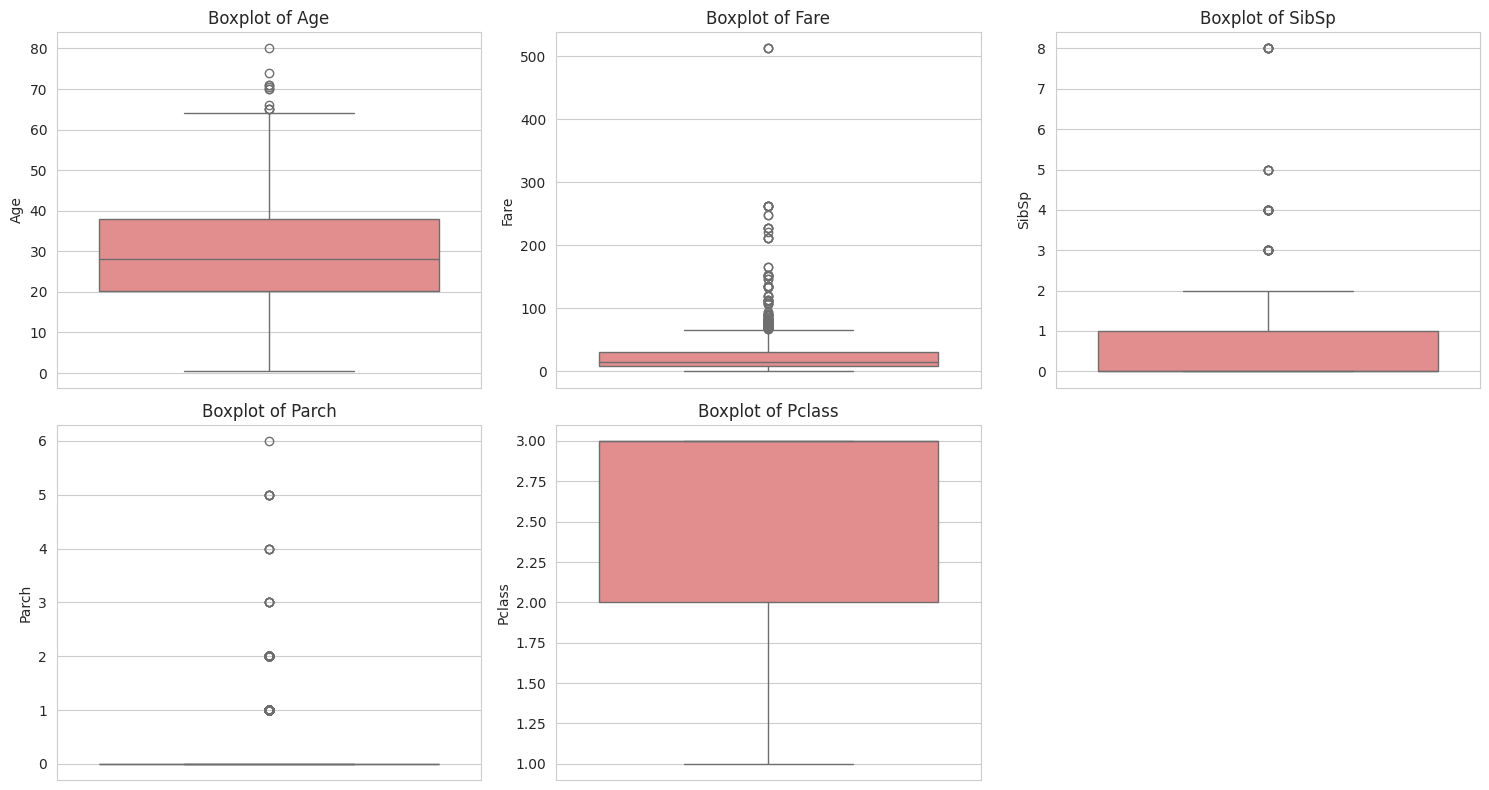

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts

df = pd.read_csv("train.csv")

num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

# Missingness heatmap
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Titanic Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

# Distribution histograms
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

# Hide the unused 6th subplot (only 5 numeric cols)
fig2.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

# Correlation heatmap
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

# Boxplots
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

fig5.delaxes(axes5[1, 2])

plt.tight_layout()
plt.show()

# Save all figures to a PDF report
from google.colab import files
pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Histograms
pdf.savefig(fig4)   # Page 3: Correlation Heatmap
pdf.savefig(fig5)   # Page 4: Boxplots

pdf.close()
files.download('EDA_Report.pdf')